This notebook is used to explore a basic comparison between CPI and synthetic data. The distribution of 2D geometric attributes are compared between the two. 
- CPI data source: 11 field campaigns from COCPIT dataset, only bullet rosettes are used for this analysis
- Synth: 70k synthetic rosette dataset is used

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [14]:
env_data_path = Path('/home/vanessa/hulk/cocpit/final_databases/vgg16/v3.1.0')
csv_files = sorted(env_data_path.glob("*.csv"))
df_cpi = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True, sort=False)

In [15]:
# env_data_path = '/home/vanessa/hulk/cocpit/final_databases/vgg16/v3.1.0/AIRS_II.csv'
# df_cpi = pd.read_csv(env_data_path)
# df_cpi.head()

In [16]:
print(list(df_cpi.columns))

['filename', 'date', 'frame width [pixels]', 'frame height [pixels]', 'particle width [microns]', 'particle height [microns]', 'cutoff [%]', 'aggregate [%]', 'budding rosette [%]', 'bullet rosette [%]', 'column [%]', 'compact irregular [%]', 'fragment [%]', 'planar polycrystal [%]', 'rimed [%]', 'sphere [%]', 'classification', 'perim [pixels]', 'hull_area [pixels]', 'convex_perim [pixels]', 'blur', 'contours [#]', 'contrast', 'cnt_area [pixels]', 'circularity', 'solidity', 'complexity', 'equiv_d', 'phi', 'extreme_points', 'filled_circular_area_ratio', 'roundness', 'perim_area_ratio', 'perim [pixels].1', 'hull_area [pixels].1', 'convex_perim [pixels].1', 'blur.1', 'contours [#].1', 'contrast.1', 'cnt_area [pixels].1', 'circularity.1', 'solidity.1', 'complexity.1', 'equiv_d.1', 'phi.1', 'extreme_points.1', 'filled_circular_area_ratio.1', 'roundness.1', 'perim_area_ratio.1']


Left: variable names in manuscript, Right: variable names in COCPIT
- aspect_ratio = phi
- aspect_ratio_elip -> not calculated in Vanessa's cocpit dataset
- extreme_pts = extreme_points
- contour_area = cnt_area [pixels]
- contour_perimeter = perim [pixels]
- area_ratio = filled_circular_area_ratio
- complexity = complexity
- circularity = circularity

In [4]:
# tabular (synthetic data)
tab_dir = '/home/jko/synth-ros-data/tabular-data-v2/shuffled_small'
tab_file = 'ros-tabular-data-shuffled-default-subset-700000.parquet'
tab_path = os.path.join(tab_dir, tab_file)
tab_stereo_2ds_file = 'ros-tabular-data-stereo-default-2ds-shuffled-subset-700000.parquet'
tab_stereo_2ds_path = os.path.join(tab_dir, tab_stereo_2ds_file)
tab_stereo_phips_file = 'ros-tabular-data-stereo-default-phips-shuffled-subset-700000.parquet'
tab_stereo_phips_path = os.path.join(tab_dir, tab_stereo_phips_file)

In [5]:
df_synth = pd.read_parquet(tab_path)
df_synth.shape

(700000, 23)

In [6]:
print(list(df_synth.columns))

['filename', 'unique_id', 'ros_id', 'proj_id', 'view', 'a', 'c', 'f_r0', 'f_hp', 'f_h0', 'n_arms', 'sa', 'vol', 'sa_eff', 'rho_eff', 'aspect_ratio', 'aspect_ratio_elip', 'extreme_pts', 'contour_area', 'contour_perimeter', 'area_ratio', 'complexity', 'circularity']


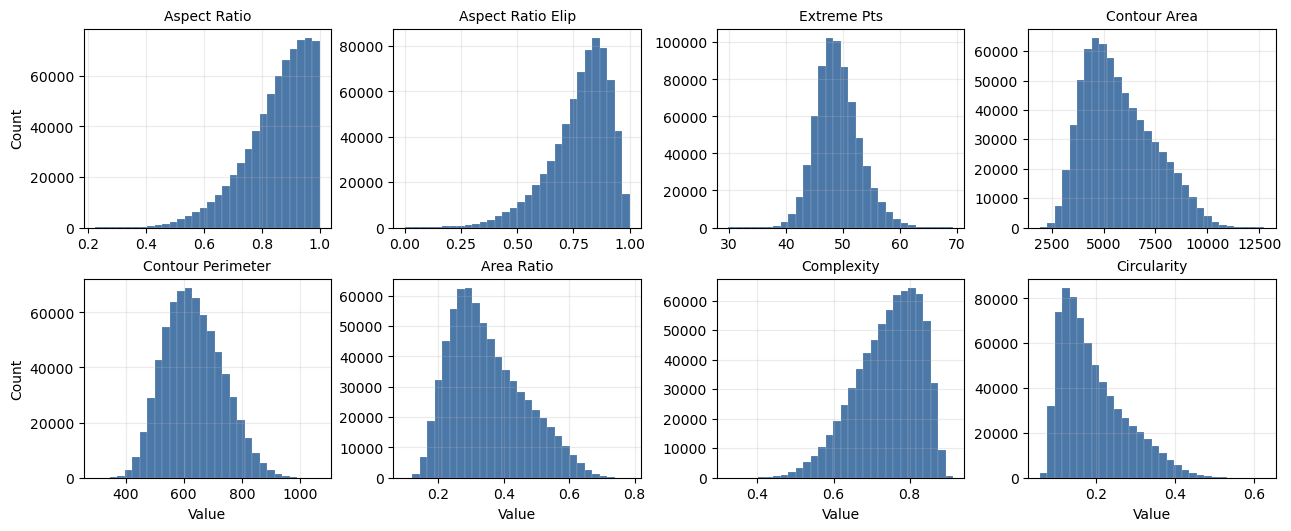

In [7]:
# Distribution of 2D attributes, Synthetic Rosettes
vars_synth = ['aspect_ratio', 'aspect_ratio_elip', 'extreme_pts', 'contour_area', 'contour_perimeter', 'area_ratio', 'complexity', 'circularity']
df = df_synth
nrows, ncols = 2, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.2, nrows*2.6), constrained_layout=True, sharey=False)

for ax, col in zip(axes.ravel(), vars_synth):
    # ensure numeric and drop NaNs
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    ax.hist(data, bins=30, color='#4c78a8', edgecolor='white', linewidth=0.1)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.grid(True, alpha=0.25)

# Optional common labels
for i, ax in enumerate(axes.ravel()):
    if i // ncols == nrows - 1:
        ax.set_xlabel('Value')
    if i % ncols == 0:
        ax.set_ylabel('Count')

# Save/show
# plt.savefig(os.path.join(savedir, 'vars_synth_hist_2x4.png'), dpi=300)
plt.show()

In [8]:
df_cpi['classification'].unique()

array(['column', 'compact irregular', 'bullet rosette', 'fragment',
       'budding rosette', 'planar polycrystal', 'aggregate', 'rimed',
       'sphere'], dtype=object)

In [19]:
df_cpi_ros = df_cpi[df_cpi['classification']=='bullet rosette'].copy()
df_cpi_ros.shape

(154222, 49)

In [20]:
# Scale factor
scale = 1000 / 224

# Variables to scale
vars_to_scale = ['cnt_area [pixels]', 'perim [pixels]']

# Apply scaling in-place
for col in vars_to_scale:
    df_cpi_ros[col] = df_cpi_ros[col] / scale

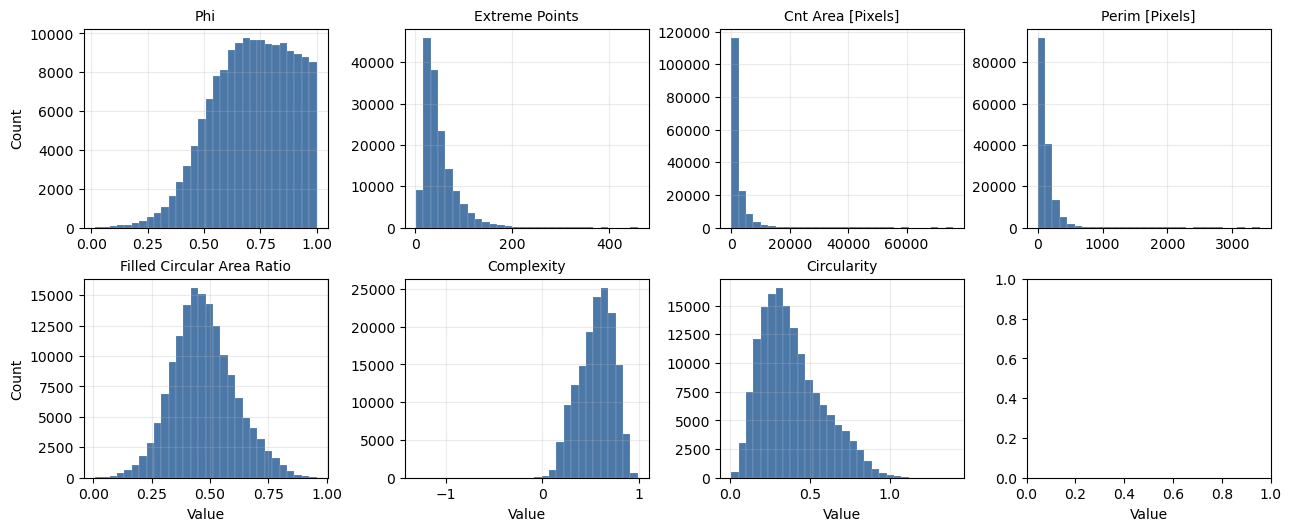

In [21]:
# Distribution of 2D attributes, CPI Rosettes
vars_cpi = ['phi', 'extreme_points', 'cnt_area [pixels]', 'perim [pixels]', 'filled_circular_area_ratio', 'complexity', 'circularity']
# df = df_cpi[(df_cpi['classification']=='budding rosette') | (df_cpi['classification']=='bullet rosette')]
df = df_cpi_ros
nrows, ncols = 2, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.2, nrows*2.6), constrained_layout=True, sharey=False)

for ax, col in zip(axes.ravel(), vars_cpi):
    # ensure numeric and drop NaNs
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    ax.hist(data, bins=30, color='#4c78a8', edgecolor='white', linewidth=0.1)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.grid(True, alpha=0.25)

# Optional common labels
for i, ax in enumerate(axes.ravel()):
    if i // ncols == nrows - 1:
        ax.set_xlabel('Value')
    if i % ncols == 0:
        ax.set_ylabel('Count')

# Save/show
# plt.savefig(os.path.join(savedir, 'vars_synth_hist_2x4.png'), dpi=300)
plt.show()

In [23]:
def print_percentiles(df_cpi, df_synth, vars_cpi, vars_synth, lower=0.10, upper=0.90):
    print("df_cpi percentiles:")
    df_cpi_bullet = df_cpi[df_cpi['classification'] == 'bullet rosette']
    for col in vars_cpi:
        q_lo = df_cpi_bullet[col].quantile(lower)
        q_hi = df_cpi_bullet[col].quantile(upper)
        print(f"{col:30s}  {int(lower*100):2d}th: {q_lo:.4f}   {int(upper*100):2d}th: {q_hi:.4f}")

    print("\ndf_synth percentiles:")
    for col in vars_synth:
        q_lo = df_synth[col].quantile(lower)
        q_hi = df_synth[col].quantile(upper)
        print(f"{col:30s}  {int(lower*100):2d}th: {q_lo:.4f}   {int(upper*100):2d}th: {q_hi:.4f}")

# Example usage:
print_percentiles(
    df_cpi_ros, df_synth,
    vars_cpi=['phi', 'extreme_points', 'cnt_area [pixels]', 'perim [pixels]', 
              'filled_circular_area_ratio', 'complexity', 'circularity'],
    vars_synth=['aspect_ratio', 'aspect_ratio_elip', 'extreme_pts', 'contour_area', 
                'contour_perimeter', 'area_ratio', 'complexity', 'circularity'],
    lower=0.25, upper=0.75  # or any percentiles you want
)

df_cpi percentiles:
phi                             25th: 0.5890   75th: 0.8570
extreme_points                  25th: 26.1150   75th: 61.2000
cnt_area [pixels]               25th: 536.3680   75th: 2506.2520
perim [pixels]                  25th: 57.4311   75th: 164.6971
filled_circular_area_ratio      25th: 0.3830   75th: 0.5580
complexity                      25th: 0.4350   75th: 0.7000
circularity                     25th: 0.2400   75th: 0.5030

df_synth percentiles:
aspect_ratio                    25th: 0.7879   75th: 0.9391
aspect_ratio_elip               25th: 0.7070   75th: 0.8773
extreme_pts                     25th: 46.4850   75th: 51.3755
contour_area                    25th: 4449.0000   75th: 6891.0000
contour_perimeter               25th: 560.8011   75th: 702.7077
area_ratio                      25th: 0.2635   75th: 0.4256
complexity                      25th: 0.6870   75th: 0.8103
circularity                     25th: 0.1279   75th: 0.2404


In [25]:
synth_var

'circularity'

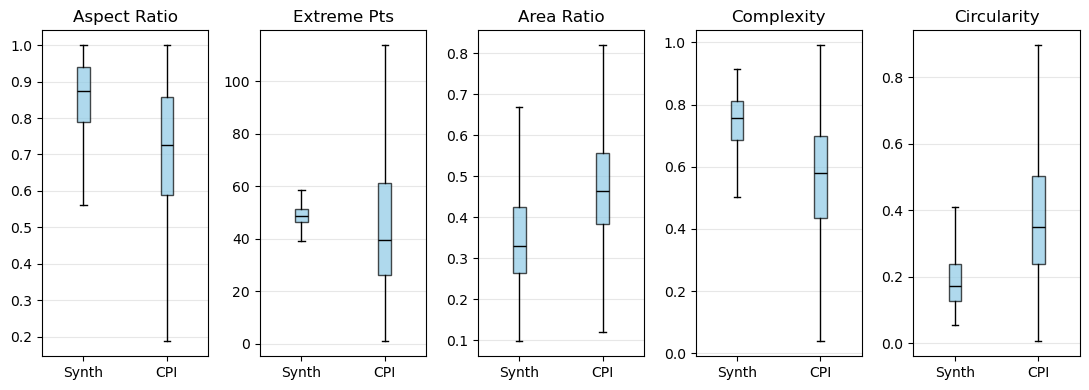

In [29]:
# Mapping of synth to cpi variables
var_map = {
    'aspect_ratio': 'phi',
    # 'aspect_ratio_elip': None,  # not in cpi
    'extreme_pts': 'extreme_points',
    'contour_area': 'cnt_area [pixels]',
    'contour_perimeter': 'perim [pixels]',
    'area_ratio': 'filled_circular_area_ratio',
    'complexity': 'complexity',
    'circularity': 'circularity'
}

var_map = {
    'aspect_ratio': 'phi',
    # 'aspect_ratio_elip': None,  # not in cpi
    'extreme_pts': 'extreme_points',
    # 'contour_area': 'cnt_area [pixels]',
    # 'contour_perimeter': 'perim [pixels]',
    'area_ratio': 'filled_circular_area_ratio',
    'complexity': 'complexity',
    'circularity': 'circularity'
}

# df_cpi_bullet = df_cpi[df_cpi['classification'] == 'bullet rosette']

n_vars = len(var_map)
fig, axes = plt.subplots(1, n_vars, figsize=(2.2 * n_vars, 4), sharey=False)  # 1 row, n_vars columns

for i, (synth_var, cpi_var) in enumerate(var_map.items()):
    ax = axes[i]
    data = [
        df_synth[synth_var].dropna(),
        df_cpi_ros[cpi_var].dropna()
    ]
    ax.boxplot(
        data,
        vert=True,
        patch_artist=True,
        tick_labels=['Synth', 'CPI'],
        showfliers=False,  # remove outliers
        boxprops=dict(facecolor='#8ecae6', alpha=0.7),
        medianprops=dict(color='k')
    )
    ax.set_title(synth_var.replace('_', ' ').title())
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
savedir = '/home/jko/ice3d-ml-paper/figs/synth-v-cpi'
os.makedirs(savedir, exist_ok=True)
savepath = os.path.join(savedir, 'synth-v-cpi-boxplots.png')
plt.savefig(savepath, dpi=300)
plt.show()